In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [19]:
# import data
zambia_cap = pd.read_csv('../../data/Zambia_CapitalAccumulation/capital_accum.csv')
lic_cap = pd.read_csv('../../data/LIC_CapitalAccumulation/LIC_cap_acc.csv')

In [20]:
zambia_clean, zambia_lookup = clean_wb_wide(zambia_cap, drop_top_rows=0)
lic_clean, lic_lookup = clean_wb_wide(lic_cap, drop_top_rows=0)

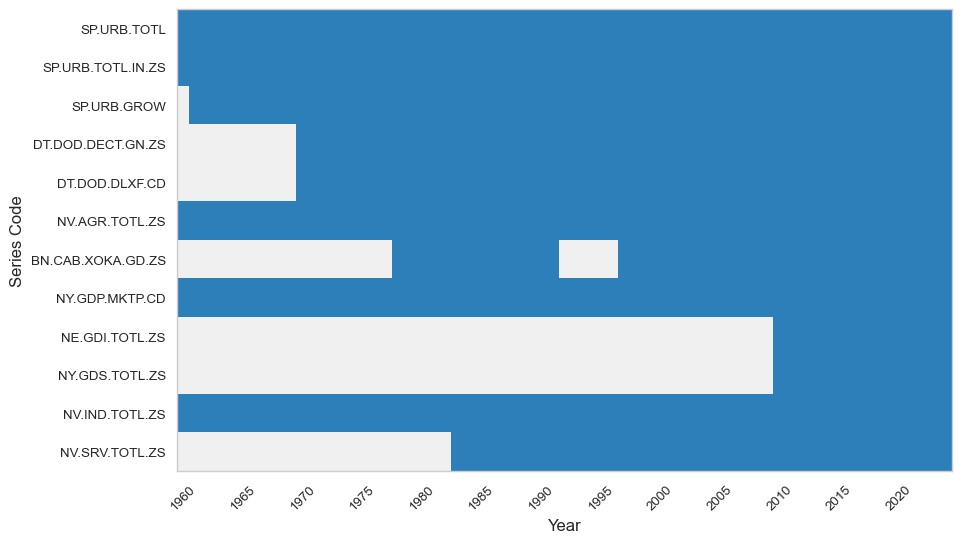

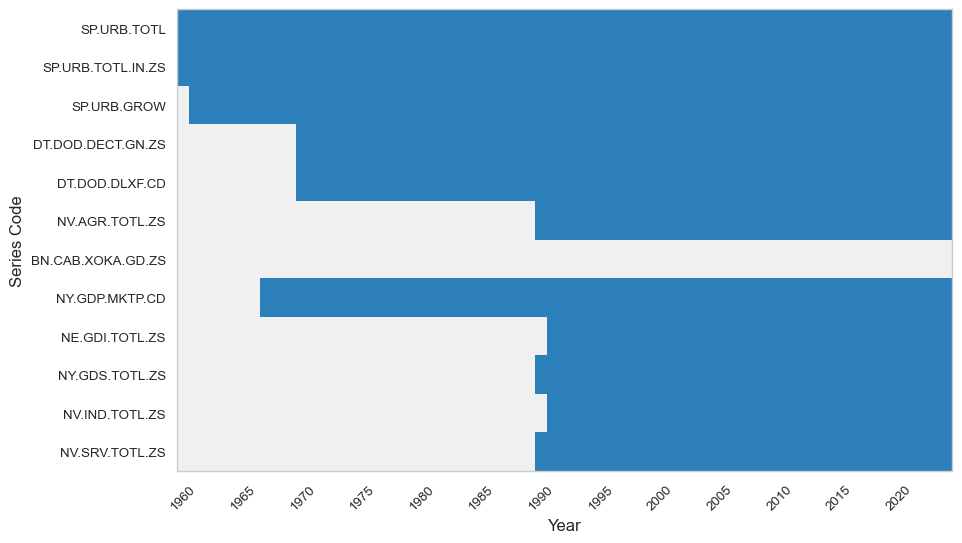

In [21]:
# plot missing data
availability_zambia, fig_zambia, ax_zambia = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup
)
availability_lic, fig_lic, ax_lic = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup
)

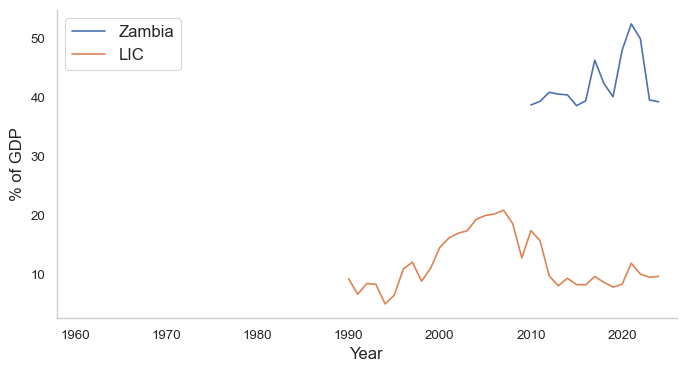

In [22]:
# gross domestic savings rate
df_zambia = zambia_clean.set_index('Year')
df_lic = lic_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['NY.GDS.TOTL.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['NY.GDS.TOTL.ZS'], label='LIC')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GDP", fontsize=12)
ax.legend(fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/GDS_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

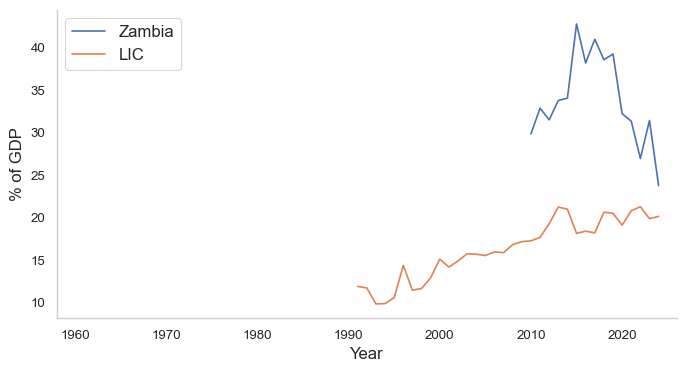

In [23]:
# capital stock as percent of GDP (Gross capital formation)
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_zambia.index, df_zambia['NE.GDI.TOTL.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['NE.GDI.TOTL.ZS'], label='LIC')
ax.legend(fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GDP", fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/GCF_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

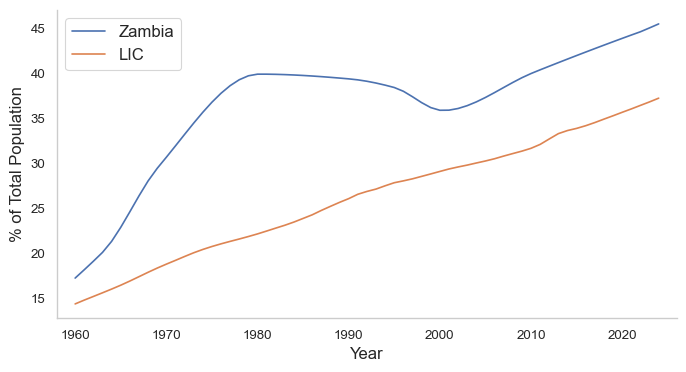

In [24]:
# urban population as percent of total population
fig, ax = plt.subplots(figsize=(8,4))

# ax.plot(df.index, df['SP.URB.TOTL.IN.ZS'])
ax.plot(df_zambia.index, df_zambia['SP.URB.TOTL.IN.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['SP.URB.TOTL.IN.ZS'], label='LIC')
ax.legend(fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of Total Population", fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/urban_pop.pdf",
    format="pdf",
    bbox_inches="tight"
)

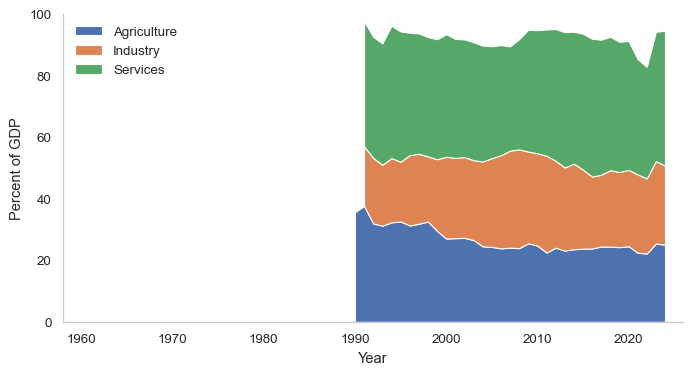

In [25]:
# structure of production: agriculture, industry, services
sectors = df_lic[['NV.AGR.TOTL.ZS',
              'NV.IND.TOTL.ZS',
              'NV.SRV.TOTL.ZS']]

fig, ax = plt.subplots(figsize=(8,4))

ax.stackplot(
    sectors.index,
    sectors['NV.AGR.TOTL.ZS'],
    sectors['NV.IND.TOTL.ZS'],
    sectors['NV.SRV.TOTL.ZS'],
    labels=['Agriculture', 'Industry', 'Services']
)

ax.set_ylabel('Percent of GDP')
ax.set_xlabel('Year')
ax.legend(frameon=False)

ax.set_ylim(0,100)
ax.set_xlim(1958, 2026)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/Production_Struction_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

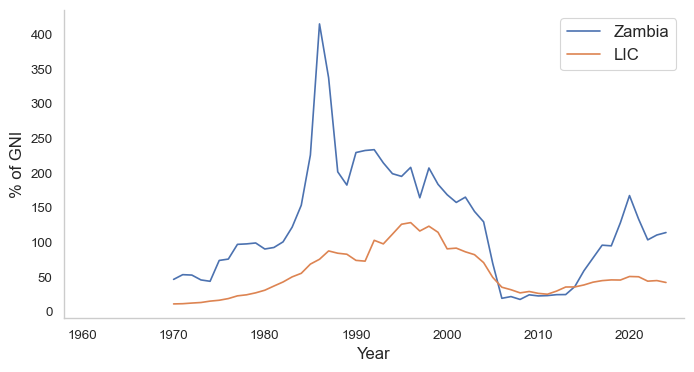

In [30]:
# total external debt
# df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

# ax.plot(df.index, df['DT.DOD.DECT.GN.ZS'])
ax.plot(df_zambia.index, df_zambia['DT.DOD.DECT.GN.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['DT.DOD.DECT.GN.ZS'], label='LIC')
ax.legend(fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GNI", fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/External_Debt_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

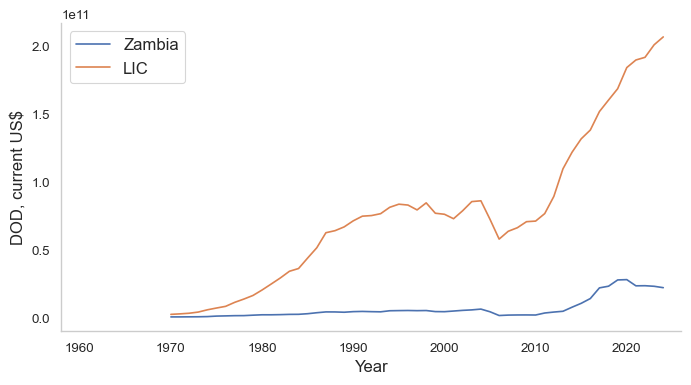

In [31]:
# total external debt
# df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

# ax.plot(df.index, df['DT.DOD.DLXF.CD'])
ax.plot(df_zambia.index, df_zambia['DT.DOD.DLXF.CD'], label='Zambia')
ax.plot(df_lic.index, df_lic['DT.DOD.DLXF.CD'], label='LIC')

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("DOD, current US$", fontsize=12)
ax.legend(fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/capital_accum/External_Debt_DDD_lic_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)